In [1]:
import anndata
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from helpers import *

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

In [2]:
# File paths
comparison_path = f"../output/MERSCOPE_WT_AD_comparison/"
output_path = f"../output/MERSCOPE_WT_AD_comparison/" + "neuropil_subdomains/"
os.makedirs(output_path, exist_ok=True)

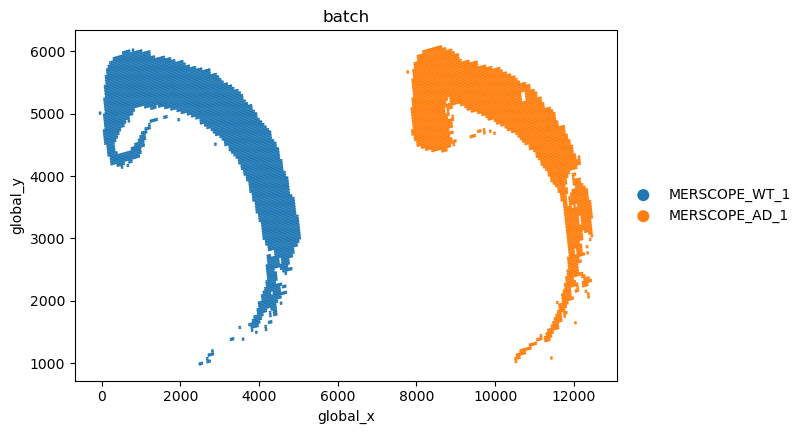

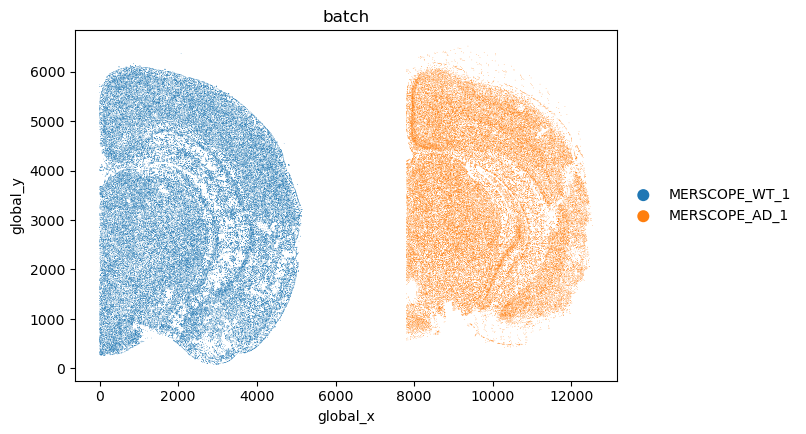

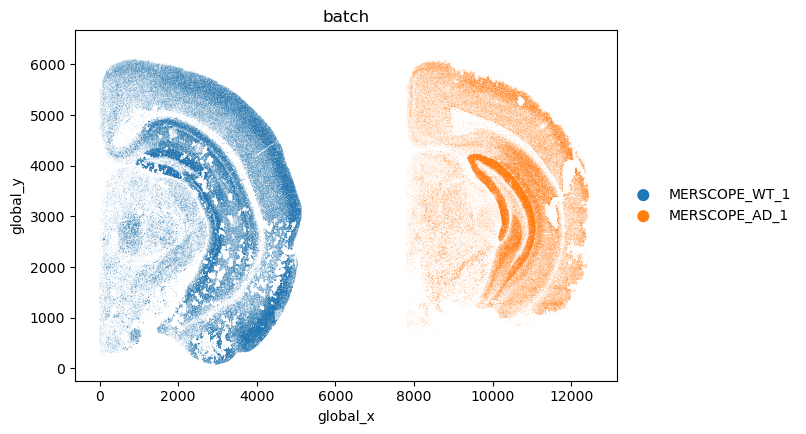

In [3]:
# ==================== Read data ==================== #

# Spots
spots = sc.read_h5ad(comparison_path + "neuropil_subdomains_spots.h5ad")
# spots = spots[spots.obs["brain_area"] != "Unknown"].copy()
# # spots = spots[spots.obs["brain_area"].isin(["Isocortex", "HPF-CA", "HPF-DG", "HPF-SR"])].copy()
spots = spots[spots.obs["brain_area"].isin(["Isocortex"])].copy()

# Cells
adata = sc.read_h5ad(comparison_path + "neuropil_subdomains_adata.h5ad")

# Granules
granule_adata = sc.read_h5ad(comparison_path + "neuropil_subdomains_granule_adata.h5ad")

# Plot check
sc.pl.scatter(spots, x="global_x", y="global_y", color="batch")
plt.show()

sc.pl.scatter(adata, x="global_x", y="global_y", color="batch")
plt.show()

sc.pl.scatter(granule_adata, x="global_x", y="global_y", color="batch")
plt.show()

In [19]:
# Compute grid-level embeddings
# embeddings, embeddings_features, aux_features, spot_granule_expression = spot_embedding(
#     spots=spots,
#     granule_adata=granule_adata,
#     adata=adata,
#     spot_width=25,
#     spot_height=25,
#     granule_subtype_key="granule_subtype_kmeans",
#     subtype_names=[str(i) for i in range(granule_adata.obs["granule_subtype_kmeans"].nunique())],
#     granule_count_layer="counts",
#     include_soma_features=True,
#     smoothing=False,
#     smoothing_radius=np.sqrt(2) * 25 + 1,
#     smoothing_mode="gaussian"
# )

# embeddings, embeddings_features, aux_features, spot_granule_expression = \
#     spot_embedding_granule_subtype_kernel_grid(
#         spots=spots,
#         granule_adata=granule_adata,
#         adata=adata,
#         spot_width=25,
#         spot_height=25,
#         granule_subtype_key="granule_subtype_kmeans",
#         subtype_names=[str(i) for i in range(granule_adata.obs["granule_subtype_kmeans"].nunique())],
#         granule_count_layer="counts",
#         include_soma_features=True,
#         kernel="gaussian",
#         sigma=12.5,
#         support_radius=37.5,
#         normalize_subtype_embedding=True,
#         normalize_gene_counts=False,
#     )

embeddings, embeddings_features, aux_features, spot_granule_expression = \
    spot_embedding_spatial_weight(
        spots=spots,
        granule_adata=granule_adata,
        adata=adata,
        spot_width=25,
        spot_height=25,
        granule_subtype_key="granule_subtype_kmeans",
        subtype_names=[str(i) for i in range(granule_adata.obs["granule_subtype_kmeans"].nunique())],
        granule_count_layer="counts",
        include_soma_features=True,
        # neighbor_mode="grid_window",   # or "radius"
        # sigma=5.0,
        # kernel="exponential",          # to mimic your old neuron code more closely
        neighbor_mode="radius",
        radius=10.0,
        sigma=5.0,
        # kernel="exponential"
        include_padding_category=False,
        normalize_subtype_embedding=True,
        normalize_gene_counts=False,
    )

for aux_key, aux_val in aux_features.items():
    print(aux_key)
    spots.obs[aux_key] = aux_val

granule_count
soma_count


In [20]:
mask = (spots.obs["granule_count"] > 0)
spots = spots[mask].copy()
embeddings = embeddings[mask].copy()
spot_granule_expression = spot_granule_expression[mask].copy()

In [21]:
# row_sums = embeddings.sum(axis=1, keepdims=True)
# X_prop = np.divide(embeddings, row_sums, out=np.zeros_like(embeddings, dtype=float), where=row_sums > 0)

In [22]:
n_clusters = 5
# LDA clustering on embeddings
lda = LatentDirichletAllocation(n_components = n_clusters, random_state = 42)
lda_labels = lda.fit_transform(embeddings)

In [23]:
spots.obs["subdomain_lda"] = [f"Substate {l + 1}" for l in np.argmax(lda_labels, axis = 1)]

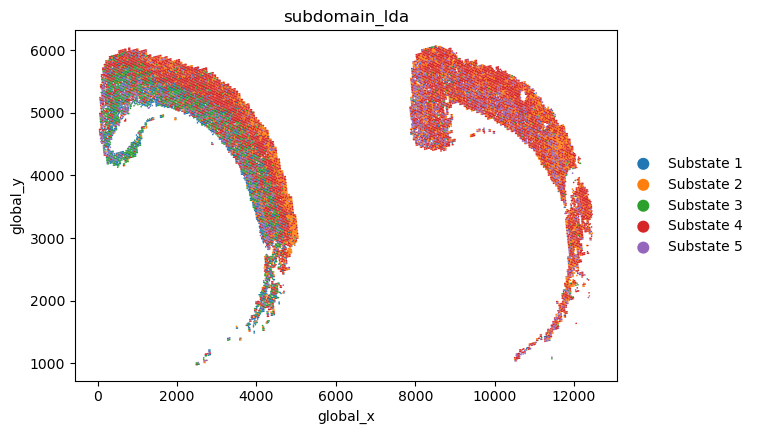

In [24]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain_lda", size=5.5, title="subdomain_lda")
plt.show()

In [ ]:
sc.pl.scatter(spots[spots.obs["subdomain_lda"] == "Substate 5"], x="global_x", y="global_y", color="subdomain_lda", size=5.5, title="subdomain_lda")
plt.show()

In [ ]:
# Evaluate ARI against K-Means on (1) granule expression and (2) extrasomatic expression

for data, label in zip([spots.X.copy(), spots.layers["extrasomatic_transcripts"].copy(), spot_granule_expression], ["total_expr", "extrasomatic_expr", "granule_expr"]):
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    sums = data.sum(axis=1, keepdims=True)
    sums[sums == 0] = 1
    data = data / sums * 1e4
    data = np.log1p(data)
    kmeans = MiniBatchKMeans(n_clusters=K, batch_size=5000, random_state=0, n_init=20)
    kmeans.fit(data)
    spots.obs[f"{label}_kmeans"] = kmeans.labels_.astype(str)
    print(f"ARI between {label} and subdomain: {adjusted_rand_score(spots.obs[f'{label}_kmeans'], spots.obs['subdomain_gmm_wtref']):.6f}")
    
    ax = sc.pl.scatter(spots, x="global_x", y="global_y", color=f"{label}_kmeans", size=5.5, title=f"{label}_kmeans", show=False)
    plt.savefig(output_path + f"{label}_kmeans.png", dpi = 500, bbox_inches = "tight")
    plt.close()